In [1]:
%load_ext autoreload
%autoreload 2

In [4]:
import sys
sys.path.append("../..")
from components.noise_generator import NoiseGenerator

from graphic_tools import rename_labels, colors

import numpy as np
import matplotlib.pyplot as plt

#### Below we generate graphical descriptions of the noise types that are currently implemented.
Note, we use the currently evaluated violation levels for depictions

# $V_{inno}$

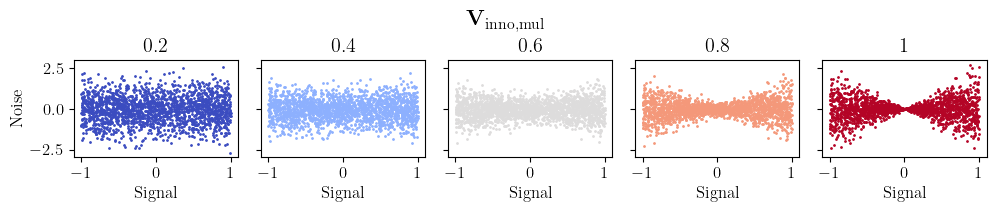

In [5]:
fig, axs = plt.subplots(1, 5, figsize=(10, 2), sharex=True, sharey=True)
random_ts = np.random.uniform(-1,1,size=(1, 2000))
violation_levels = [0.2,0.4,0.6,0.8,1]
for n, x in enumerate(violation_levels):

    N = NoiseGenerator(
        modus="inno",
        additive=True,
        multiplicative=True,
        non_additive_noise_proba=x,       
    )
    noise = N.get_noise(random_ts)
    _ = axs[n].scatter(random_ts.flatten(), noise.flatten(), s=1, color=colors[n])

    axs[n].set_title(f"{x}")
    axs[n].set_xlabel("Signal")
axs[0].set_ylabel("Noise")
plt.tight_layout()

fig.suptitle(
    rename_labels["inno_mul"],
    fontsize=16,
    y=1.05,
)


plt.savefig("../img/multiplicative_noise.pdf", bbox_inches='tight', dpi=500)

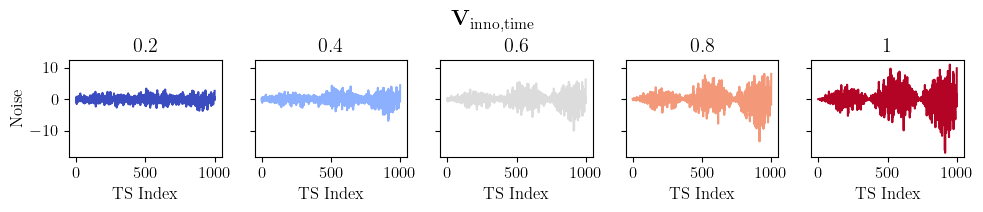

In [101]:
fig, axs = plt.subplots(1, 5, figsize=(10, 2), sharex=True, sharey=True)
random_ts = np.random.uniform(size=(1, 1000))
violation_levels = [0.2,0.4,0.6,0.8,1]

for n, x in enumerate(violation_levels):
    N = NoiseGenerator(
        modus="inno",
        time_dependent=True,
        non_additive_noise_proba=x,
    )

    _ = axs[n].plot(N.get_noise(random_ts).T, color=colors[n])
    axs[n].set_title(f"{x}")
    axs[n].set_xlabel("TS Index")
axs[0].set_ylabel("Noise")
plt.tight_layout()
fig.suptitle(
    rename_labels["inno_time"],
    fontsize=16,
    y=1.05,
)

plt.savefig("../img/time.pdf", bbox_inches='tight')

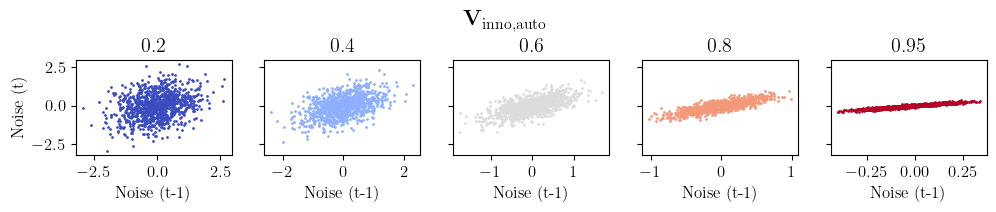

In [90]:
fig, axs = plt.subplots(1, 5, figsize=(10, 2),sharey=True)
random_ts = np.random.uniform(size=(1, 1000))
violation_levels = [0.2,0.4,0.6,0.8,0.95]

for n, x in enumerate(violation_levels):
    N = NoiseGenerator(
        modus="inno",
        autoregressive=True,
        non_additive_noise_proba=x,
    )
    noise = []
    for i in range(random_ts.shape[1] - 1):
        noise.append(N.get_noise(random_ts[:,i: i+1]).T)
    _ = axs[n].scatter(noise[1:], noise[:-1], s=1, color=colors[n])
    axs[n].set_title(f"{x}")
    axs[n].set_xlabel("Noise (t-1)")
axs[0].set_ylabel("Noise (t)")
plt.tight_layout()
fig.suptitle(
    rename_labels["inno_auto"],
    fontsize=16,
    y=1.05,
)
plt.savefig("../img/auto.pdf", bbox_inches='tight', dpi=500)

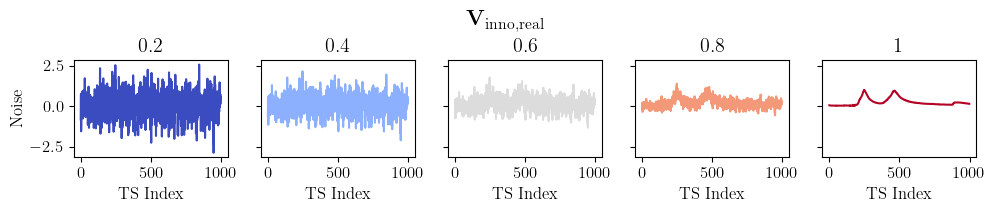

In [91]:
fig, axs = plt.subplots(1, 5, figsize=(10, 2),sharey=True)
random_ts = np.random.uniform(size=(1, 1000))
violation_levels = [0.2, 0.4, 0.6, 0.8, 1]

for n, x in enumerate(violation_levels):
    N = NoiseGenerator(
        modus="inno",
        non_additive_noise_proba = x,
        semi_synthetic=True,
        semi_synthetic_noise_path = "../semi_synthetic_bases/"
        )
    noise = []
    for i in range(random_ts.shape[1] - 1):
        noise.append(N.get_noise(random_ts[:,i: i+1]).T[0])
    _    = axs[n].plot(np.array(noise) , color=colors[n])
    axs[n].set_title(f"{x}")
    axs[n].set_xlabel("TS Index")
axs[0].set_ylabel("Noise")
plt.tight_layout()
fig.suptitle(
    rename_labels["inno_real"],
    fontsize=16,
    y=1.05,
)
plt.savefig("../img/real.pdf", bbox_inches='tight', dpi=500)

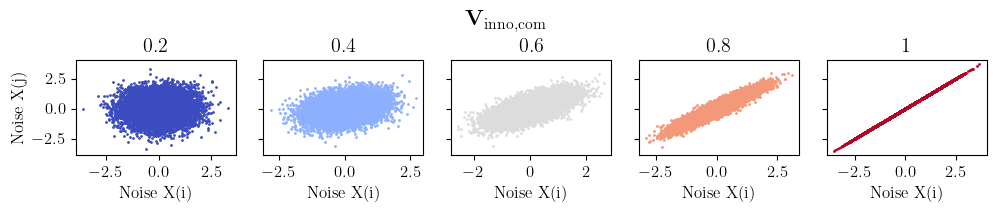

In [92]:
fig, axs = plt.subplots(1, 5, figsize=(10, 2),sharey=True)
random_ts = np.random.uniform(size=(2, 10000))
violation_levels = [0.2,0.4,0.6,0.8,1]

for n, x in enumerate(violation_levels):
    N = NoiseGenerator(
        modus="inno",
        common=True,
        non_additive_noise_proba=x,
        snr=0
    )
    noise = N.get_noise(random_ts).T
    _ = axs[n].scatter(noise[:,0], noise[:,1], s=1, color=colors[n])
    axs[n].set_title(f"{x}")
    axs[n].set_xlabel("Noise X(i)")
axs[0].set_ylabel("Noise X(j)")
plt.tight_layout()
fig.suptitle(
    rename_labels["inno_common"],
    fontsize=16,
    y=1.05,
)
plt.savefig("../img/common.pdf", bbox_inches='tight', dpi=500)

## $V_{inno,weib,uni}$

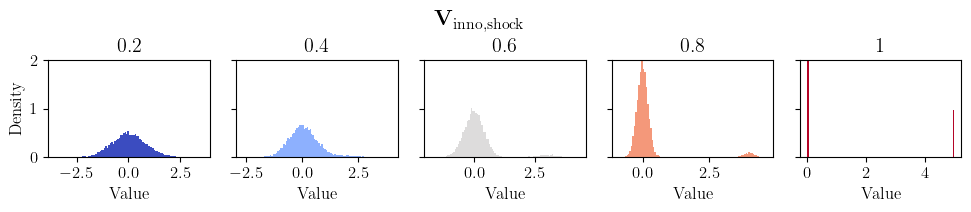

In [96]:
fig, axs = plt.subplots(1, 5, figsize=(10, 2),sharey=True)
random_ts = np.random.uniform(size=(1, 10000))
violation_levels = [0.2,0.4,0.6,0.8,1]
for n, x in enumerate(violation_levels):
    N = NoiseGenerator(
        modus="inno",
        additive=True,
        shock=True,
        non_additive_noise_proba=x,
        snr=0
    )
    _ = axs[n].hist(N.get_noise(random_ts).T, bins=100,color= colors[n], density=True )
    axs[n].set_title(f"{x}")
    axs[n].set_xlabel("Value")
axs[0].set_ylabel("Density")
#   axs[0].set_yticks([])
axs[0].set_ylim(0, 2)

plt.tight_layout()
fig.suptitle(
    rename_labels["inno_shock"],
    fontsize=16,
    y=1.05,
)
plt.savefig("../img/shock.pdf", bbox_inches='tight')

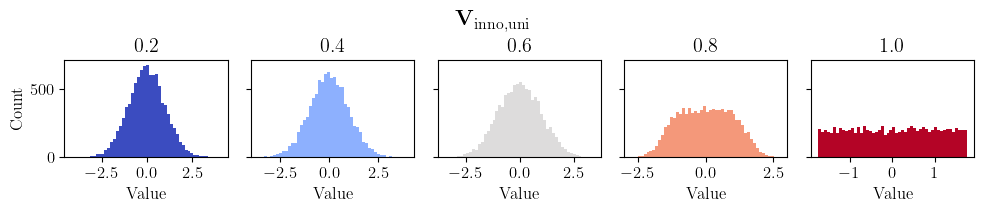

In [97]:
# Nongaussian mixture.
fig, axs = plt.subplots(1, 5, figsize=(10, 2), sharey=True)
random_ts = np.random.uniform(size=(1, 10000))
for n, x in enumerate([0.2,0.4,0.6,0.8,1.0]):
    N = NoiseGenerator(
        modus="inno",
        additive=True,
        non_gaussian_additive=x,
        which_non_gaussian="uniform",
        snr=0
    )
    _ = axs[n].hist(N.get_noise(random_ts).T, bins=50, color=colors[n])
    axs[n].set_title(f"{x}")
    axs[n].set_xlabel("Value")
  
axs[0].set_ylabel("Count")
plt.tight_layout()
#axs[0].set_yticks([])



fig.suptitle(
    rename_labels["inno_uniform"],
    fontsize=16,
    y=1.05,
)

plt.savefig("../img/uniform.pdf", bbox_inches='tight', dpi=500)

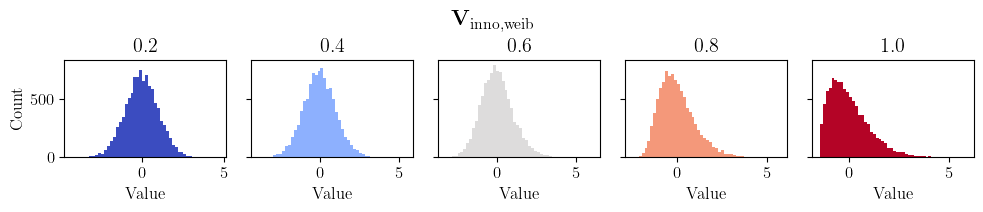

In [99]:
fig, axs = plt.subplots(1, 5, figsize=(10, 2), sharey=True)
random_ts = np.random.uniform(size=(1, 10000))
for n, x in enumerate([0.2,0.4,0.6,0.8,1.0]):
    N = NoiseGenerator(
        modus="inno",
        additive=True,
        non_gaussian_additive=x,
        which_non_gaussian="weibull",
        snr=0
    )
    _ = axs[n].hist(N.get_noise(random_ts).T, bins=50, color=colors[n])
    axs[n].set_title(f"{x}")
    axs[n].set_xlabel("Value")

axs[0].set_ylabel("Count")
plt.tight_layout()
#axs[0].set_yticks([])

fig.suptitle(
    rename_labels["inno_weibull"],
    fontsize=16,
    y=1.05,
)
plt.savefig("../img/weibull.pdf", bbox_inches='tight')

## $V_{inno,var}$

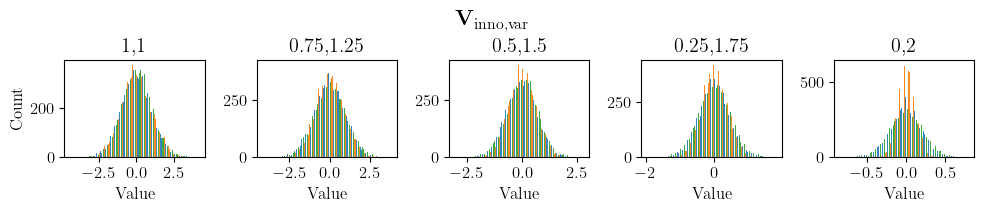

In [100]:
fig, axs = plt.subplots(1, 5, figsize=(10, 2), sharey=False)
random_ts = np.random.uniform(size=(3, 10000))

for n, x in enumerate([[1,1,1,1],[0.75,1,1,1.25],[0.5,0.75,1.125,1.5],[0.25,0.5,1.5,1.75],[0,0.25,1.75,2]]):
    N = NoiseGenerator(
        modus="inno",
        additive=True,
        non_equal_variance_range=x
    )
    noise = N.get_noise(random_ts)
    _ = axs[n].hist(noise.T, bins=100, alpha=0.9)
    axs[n].set_title(str(x[0]) + "," + str(x[-1]))
    axs[n].set_xlabel("Value")
    #axs[n].set_yticks([])

axs[0].set_ylabel("Count")
plt.tight_layout()


fig.suptitle(
    rename_labels["inno_var"],
    fontsize=16,
    y=1.05,
)


plt.savefig("../img/unequal_var.pdf", bbox_inches='tight')

# $V_{obs}$

In [63]:
snr_levels = [1,0.75,0.5,0.25,0.05]

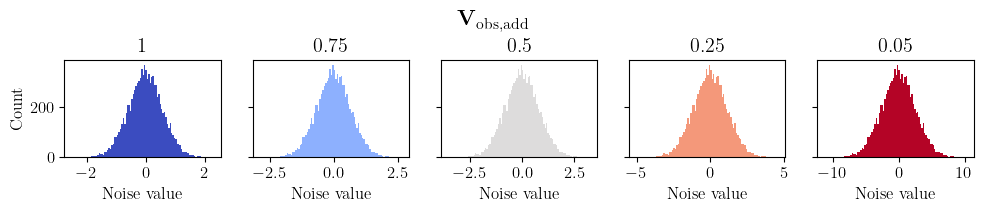

In [79]:
random_ts = np.random.uniform(-1,1,size=(1, 10000))

fig, axs = plt.subplots(1, 5, figsize=(10, 2), sharey=True)

for n, x in enumerate(snr_levels):
    N = NoiseGenerator(
        modus="obs",
        additive=True,
        snr=x
    )
    noise = N.get_noise(random_ts)
    _ = axs[n].hist(noise.T, bins=100,color= colors[n])
    axs[n].set_title(f"{x}")
    axs[n].set_xlabel("Noise value")
axs[0].set_ylabel("Count")
#axs[0].set_yticks([])
plt.tight_layout()
fig.suptitle(
    rename_labels["obs_add"],
    fontsize=16,
    y=1.05,
)
plt.savefig("../img/add_obs.pdf", bbox_inches='tight', dpi=500)

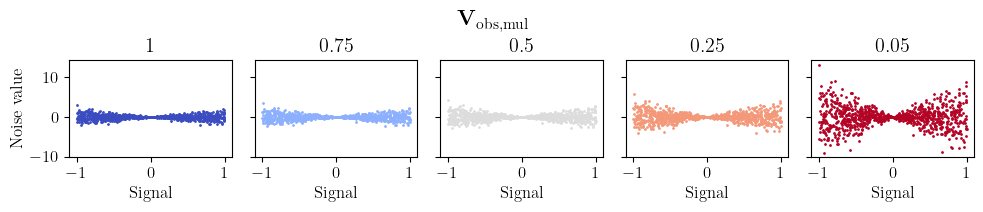

In [80]:
fig, axs = plt.subplots(1, 5, figsize=(10, 2), sharey=True)
random_ts = np.random.uniform(-1,1,size=(1, 1000))

for n, x in enumerate(snr_levels):
    N = NoiseGenerator(
        modus="obs",
        additive=False,
        multiplicative=True,
        snr=x
    )
    noise = N.get_noise(random_ts)
    _ = axs[n].scatter(random_ts, noise, s=1,color= colors[n])
    axs[n].set_title(f"{x}")
    axs[n].set_xlabel("Signal")
axs[0].set_ylabel("Noise value")
#axs[0].set_yticks([])
plt.tight_layout()
fig.suptitle(
    rename_labels["obs_mul"],
    fontsize=16,
    y=1.05,
)
plt.savefig("../img/mul_obs.pdf", bbox_inches='tight', dpi=500)

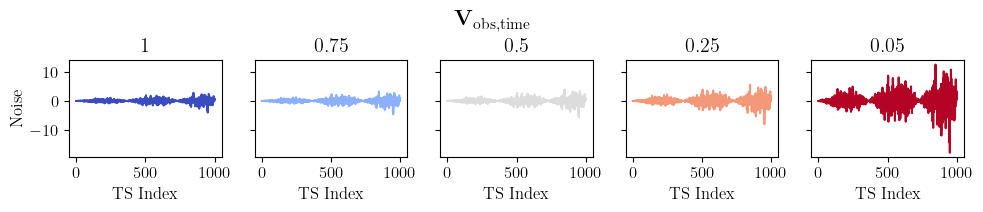

In [81]:
fig, axs = plt.subplots(1, 5, figsize=(10, 2), sharey=True)
random_ts = np.random.uniform(size=(1, 1000))

for n, x in enumerate(snr_levels):
    N = NoiseGenerator(
        modus="obs",
        additive=False,
        time_dependent=True,
        snr=x
    )
    noise = N.get_noise(random_ts)
    _ = axs[n].plot( noise.T,color= colors[n])
    axs[n].set_title(f"{x}")
    axs[n].set_xlabel("TS Index")
axs[0].set_ylabel("Noise")
#axs[0].set_yticks([])

plt.tight_layout()
fig.suptitle(
    rename_labels["obs_time"],
    fontsize=16,
    y=1.05,
)
plt.savefig("../img/time_obs.pdf", bbox_inches='tight')

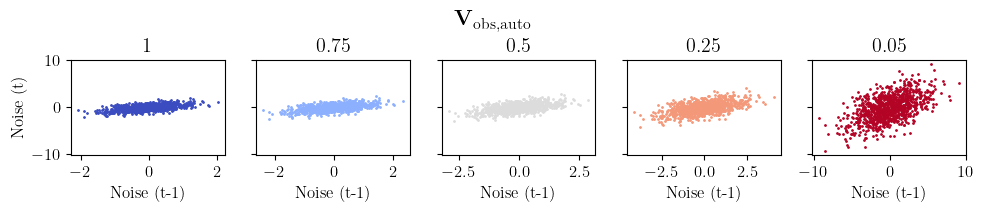

In [83]:
fig, axs = plt.subplots(1, 5, figsize=(10, 2), sharey=True)
random_ts = np.random.uniform(size=(1, 1000))

for n, y in enumerate(snr_levels):
    N = NoiseGenerator(
        modus="obs",
        autoregressive=True,
        additive=False,
        snr=y
    )
    noise = N.get_noise(random_ts).T
    _ = axs[n].scatter(noise[1:], noise[:-1], s=1,color= colors[n])
    axs[n].set_title(f"{y}")
    axs[n].set_xlabel("Noise (t-1)")
axs[0].set_ylabel("Noise (t)")
plt.tight_layout()

fig.suptitle(
    rename_labels["obs_auto"],
    fontsize=16,
    y=1.05,
)
plt.savefig("../img/auto_obs.pdf", bbox_inches='tight')

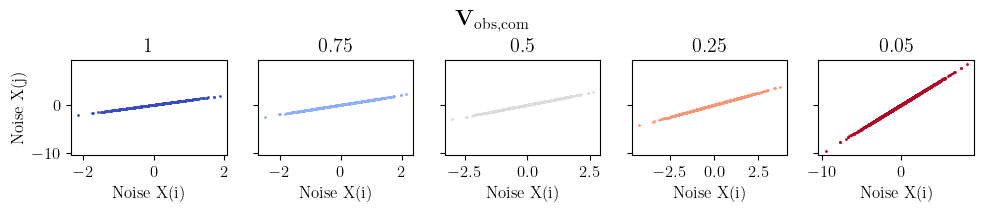

In [85]:
fig, axs = plt.subplots(1, 5, figsize=(10, 2), sharey=True)
random_ts = np.random.uniform(size=(2, 1000))


for n, x in enumerate(snr_levels):
    N = NoiseGenerator(
        modus="obs",
        common=True,
        additive=False,
        snr=x
    )
    noise = N.get_noise(random_ts).T
    _ = axs[n].scatter(noise[:,0], noise[:,1], s=1, color=colors[n])

    axs[n].set_title(f"{x}")
    axs[n].set_xlabel("Noise X(i)")
axs[0].set_ylabel("Noise X(j)")
plt.tight_layout()
fig.suptitle(
    rename_labels["obs_common"],
    fontsize=16,
    y=1.05,
)
plt.savefig("../img/common_obs.pdf", bbox_inches='tight')

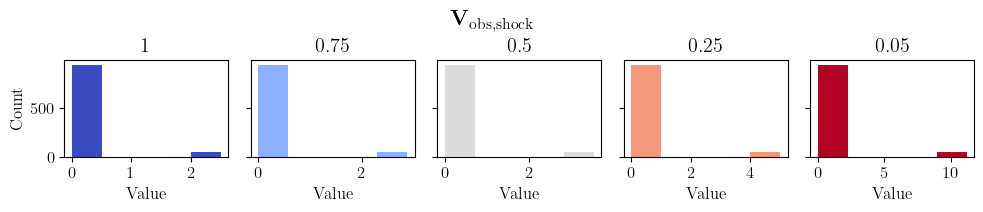

In [ ]:
fig, axs = plt.subplots(1, 5, figsize=(10, 2),sharey=True)
random_ts = np.random.uniform(size=(1, 1000))

for n, x in enumerate(snr_levels):
    N = NoiseGenerator(
        modus="obs",
        shock=True,
        additive=False,
        snr=x
    )
    noise = N.get_noise(random_ts)
    _ = axs[n].hist(noise.T, bins=5,color= colors[n])
    axs[n].set_title(f"{x}")
    axs[n].set_xlabel("Value")
axs[0].set_ylabel("Count")
#axs[0].set_yticks([])
plt.tight_layout()
fig.suptitle(
    rename_labels["obs_shock"],
    fontsize=16,
    y=1.05,
)
plt.savefig("../img/shock_obs.pdf", bbox_inches='tight')

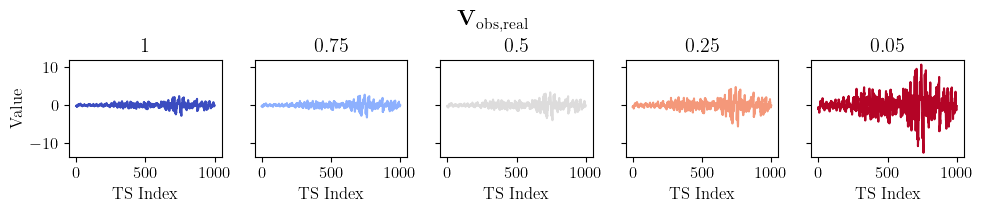

In [88]:
fig, axs = plt.subplots(1, 5, figsize=(10, 2),sharey=True)
random_ts = np.random.uniform(size=(1, 1000))

for n, x in enumerate(snr_levels):
    N = NoiseGenerator(
        modus="obs",
        semi_synthetic=True,
        rng=2,
        additive=False,
        snr=x,
        semi_synthetic_noise_path="../semi_synthetic_bases/"
    )
    noise = N.get_noise(random_ts)
    _ = axs[n].plot( noise.T,color= colors[n])
    axs[n].set_title(f"{x}")
    axs[n].set_xlabel("TS Index")
axs[0].set_ylabel("Value")
#axs[0].set_yticks([])

plt.tight_layout()
fig.suptitle(
    rename_labels["obs_real"],
    fontsize=16,
    y=1.05,
)
plt.savefig("../img/real_obs.pdf", bbox_inches='tight')